# The forgetting curve — what continued pretraining costs on a holdout

**The setup.** `run11` is a HuBERT pretrained from scratch on 116 h of zebra finch colony audio.
AVES is the *same architecture* (94,370,944 parameters, identical `state_dict` keys) pretrained on
360 h of generic animal and environmental audio. AVES wins nearly everywhere, so the obvious move is
**DAPT** — domain-adaptive pretraining: start from AVES and keep pretraining on our corpus, so the
model gets the general representation *and* the domain.

**What round 1 reported.** At 15,000 steps DAPT beat run11 in-distribution and fell *through* the
BirdPark energy floor — catastrophic forgetting, reported as a failure under a pre-committed stop
rule rather than rescued by hunting for a flattering layer.

**What this notebook adds.** Round 1 measured the *endpoint*. Six evenly spaced checkpoints per
learning rate were saved but never scored, so *when* the collapse happened was unknown — and that
distinction decides whether the fix is "train less" or "train differently". This scores all of them.

**The result, and it is not the tidy one.** The holdout trajectory is NON-MONOTONIC, and the two
learning rates trace *opposite* shapes: 5e-5 starts high and falls, 1e-4 starts low and rises before
falling. Only 2 of 12 checkpoints clear the energy floor and they sit at incompatible positions
(step 2,500 at the low rate, step 10,000 at the high one). Set against a BirdPark AP interval of
roughly +/-0.06, that is what scatter looks like, not a schedule anyone could have chosen in advance.

**What survives the noise.** All 12 checkpoints score below BOTH parents -- run11 and AVES -- and
10 of 12 fall below the energy floor. And in-distribution AUC moves by 0.002 across the whole
trajectory while holdout AP moves by 0.14, a 50-70x amplification: the criterion used to pick the
arm carries essentially no information about the holdout.

**An earlier draft of this notebook claimed a clean monotone forgetting curve.** That reading came
from the 5e-5 arm before the 1e-4 arm had finished scoring, and the completed data refutes it. It is
recorded here rather than quietly deleted because it is the exact mistake this project's evaluation
doctrine exists to prevent: six points moving one way is not a trend when the measurement cannot
resolve the steps between them.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ANA = Path.home() / "zf_labelset/zf_detection_dataset_v1/analysis"
D = json.loads((ANA / "detection_variants.json").read_text())
PC = D["precommit"]

ENERGY = D["zf_to_bp"]["logenergy"]["L0"]            # the pre-committed stop rule
print(f"ZF->BirdPark log-energy baseline: AUC {ENERGY['auc']:.4f}  AP {ENERGY['ap']:.4f}")
print("This is the floor. An encoder scoring below it has forgotten more than it learned.")

def row(name):
    j = PC[name]["joint"]
    return dict(name=name, arm=f"{j['tag']}_L{j['layer']}",
                zf_auc=j["zf"]["auc"], zf_ap=j["zf"]["ap"],
                bp_auc=j["bp"]["auc"], bp_ap=j["bp"]["ap"])

traj = {}
for k in PC:
    if not k.startswith("dapt"):
        continue
    lr, step = k.split("_step")
    traj.setdefault(lr[4:], []).append((int(step), row(k)))
for lr in traj:
    traj[lr].sort()
print("\ntrajectories found:", {k: [s for s, _ in v] for k, v in traj.items()})

ZF->BirdPark log-energy baseline: AUC 0.8542  AP 0.7472
This is the floor. An encoder scoring below it has forgotten more than it learned.

trajectories found: {'5e5': [2500, 5000, 7500, 10000, 12500, 15000], '1e4': [2500, 5000, 7500, 10000, 12500, 15000]}


## The trajectory table

The arm is **pre-committed on ZF**: for each checkpoint the layer and normalisation are chosen by
out-of-fold AUC on in-distribution zebra finch audio, and BirdPark is then scored at that choice
only. This matters — with six layers × two normalisations × many checkpoints there are hundreds of
chances to find a winner on a 5,925-frame test set, and a maximum over hundreds is not a
measurement. Every layer is written to the JSON so the choice stays auditable.

In [2]:
rows = []
for lr, items in sorted(traj.items()):
    for step, r in items:
        rows.append(dict(lr=lr, step=step, arm=r["arm"], zf_auc=r["zf_auc"],
                         bp_auc=r["bp_auc"], bp_ap=r["bp_ap"],
                         vs_floor=r["bp_ap"] - ENERGY["ap"]))
T = pd.DataFrame(rows)
T["cleared_floor"] = np.where(T.vs_floor >= 0, "yes", "NO")
ref = {k: row(k) for k in ("run11", "aves-base-bio", "birdaves-bioxn-large") if k in PC}
print("reference encoders (same pre-commitment procedure):")
for k, r in ref.items():
    print(f"  {k:22s} {r['arm']:12s} ZF AUC {r['zf_auc']:.4f}  BP AP {r['bp_ap']:.4f}")
print()
display(T.style.format({"zf_auc": "{:.4f}", "bp_auc": "{:.4f}",
                        "bp_ap": "{:.4f}", "vs_floor": "{:+.4f}"}).hide(axis="index"))

reference encoders (same pre-commitment procedure):
  run11                  matched_L0   ZF AUC 0.9687  BP AP 0.8121
  aves-base-bio          matched_L6   ZF AUC 0.9674  BP AP 0.8057
  birdaves-bioxn-large   matched_L12  ZF AUC 0.9724  BP AP 0.8442



lr,step,arm,zf_auc,bp_auc,bp_ap,vs_floor,cleared_floor
1e4,2500,native_L6,0.9693,0.7131,0.6105,-0.1366,NO
1e4,5000,native_L6,0.9698,0.7647,0.6884,-0.0587,NO
1e4,7500,native_L6,0.9702,0.7665,0.7067,-0.0404,NO
1e4,10000,native_L6,0.9716,0.8099,0.7515,+0.0043,yes
1e4,12500,native_L6,0.9715,0.7938,0.7240,-0.0232,NO
1e4,15000,native_L6,0.9720,0.7792,0.7052,-0.0420,NO
5e5,2500,native_L6,0.9697,0.8342,0.7725,+0.0254,yes
5e5,5000,native_L6,0.9705,0.7978,0.7259,-0.0212,NO
5e5,7500,native_L6,0.9712,0.7509,0.6768,-0.0704,NO
5e5,10000,native_L6,0.9715,0.7580,0.6808,-0.0664,NO


## The picture, with an honest error bar on it

Left: in-distribution detection -- what you would watch if you only had your own data. Right: the
held-out recordings, with the energy floor drawn in and a shaded band showing the approximate
resolution of this test set.

Two things to read off it. First, **if you only ever measured in-distribution, every one of these
checkpoints looks like an improvement over run11** -- the left panel is flat-to-rising throughout
while the right panel is below both parents throughout. Second, **the right panel's wiggles are
mostly inside the band.** The gap between DAPT and its parents is real; the ordering of checkpoints
within a trajectory is not.

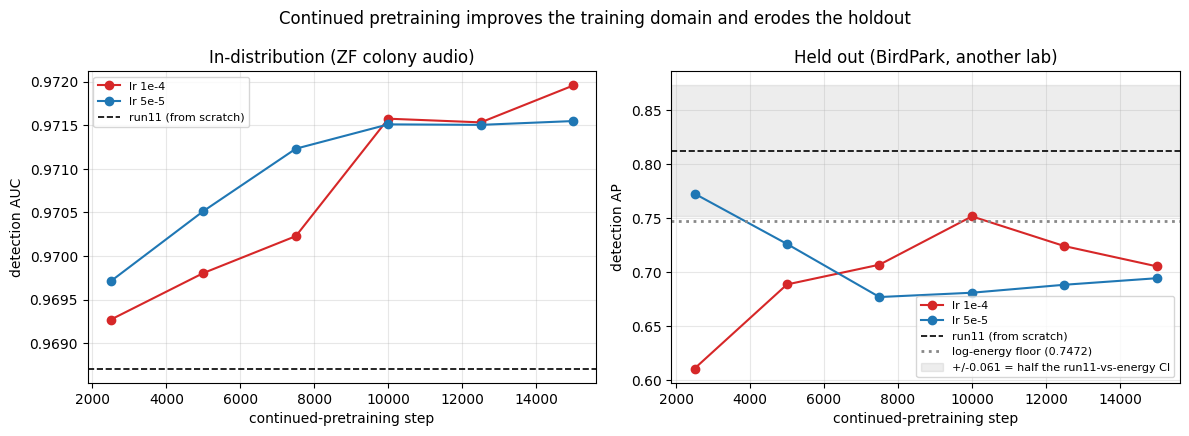

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
colors = {"5e5": "#1f77b4", "1e4": "#d62728"}
label = {"5e5": "lr 5e-5", "1e4": "lr 1e-4"}

for lr, items in sorted(traj.items()):
    steps = [s for s, _ in items]
    ax[0].plot(steps, [r["zf_auc"] for _, r in items], "o-",
               color=colors.get(lr, None), label=label.get(lr, lr))
    ax[1].plot(steps, [r["bp_ap"] for _, r in items], "o-",
               color=colors.get(lr, None), label=label.get(lr, lr))

for a, key, title, yl in ((ax[0], "zf_auc", "In-distribution (ZF colony audio)", "detection AUC"),
                          (ax[1], "bp_ap", "Held out (BirdPark, another lab)", "detection AP")):
    if "run11" in ref:
        a.axhline(ref["run11"][key], ls="--", lw=1.2, color="k", label="run11 (from scratch)")
    a.set_title(title); a.set_xlabel("continued-pretraining step"); a.set_ylabel(yl)
    a.grid(alpha=0.3)
ax[1].axhline(ENERGY["ap"], ls=":", lw=2, color="#888",
              label=f"log-energy floor ({ENERGY['ap']:.4f})")
# Resolution band, taken from the project's own BirdPark bootstrap rather than invented: the
# run11-vs-energy comparison returns a 95% interval about this wide and is reported
# "not_distinguishable". Differences narrower than this band are not measurements.
_b = D["bootstrap"]["run11_vs_logenergy"]["bp_ap_block1500"]
_half = (_b["hi"] - _b["lo"]) / 2
if "run11" in ref:
    ax[1].axhspan(ref["run11"]["bp_ap"] - _half, ref["run11"]["bp_ap"] + _half,
                  color="k", alpha=0.07,
                  label=f"+/-{_half:.3f} = half the run11-vs-energy CI")
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
fig.suptitle("Continued pretraining improves the training domain and erodes the holdout",
             fontsize=12)
fig.tight_layout()
plt.show()

## How much of the holdout gap is the *arm*, not the model?

A caution that outlives this experiment. The arm is chosen by in-distribution AUC, and that
criterion has almost no resolution against the holdout: candidate arms sit within a few
ten-thousandths of each other on ZF while spanning an order of magnitude more on BirdPark. So the
selection step can move the reported holdout number by more than any difference between models.

The cell below quantifies it per checkpoint: the ZF spread across the layer grid, against the
BirdPark spread across the same grid.

In [4]:
rows = []
for lr, items in sorted(traj.items()):
    for step, _ in items:
        name = f"dapt{lr}_step{step}"
        zf = D["in_distribution"][name]; bp = D["zf_to_bp"][name]
        zfv = np.array([v["auc"] for v in zf.values()])
        bpv = np.array([bp[k]["ap"] for k in zf])
        rows.append(dict(lr=lr, step=step, n_arms=len(zfv),
                         zf_auc_spread=zfv.max() - zfv.min(),
                         bp_ap_spread=bpv.max() - bpv.min(),
                         best_bp_ap=bpv.max(),
                         amplification=(bpv.max() - bpv.min()) / max(zfv.max() - zfv.min(), 1e-9)))
S = pd.DataFrame(rows)
display(S.style.format({"zf_auc_spread": "{:.4f}", "bp_ap_spread": "{:.4f}",
                        "best_bp_ap": "{:.4f}", "amplification": "{:.0f}x"}).hide(axis="index"))
print("\n'amplification' = how many times wider the holdout spread is than the spread of the "
      "criterion used to choose among those same arms.")
print("best_bp_ap is the POST-HOC maximum. It is printed to show the selection risk, and must "
      "not be quoted as a result -- it is a max over the test set.")

lr,step,n_arms,zf_auc_spread,bp_ap_spread,best_bp_ap,amplification
1e4,2500,12,0.0136,0.2604,0.8579,19x
1e4,5000,12,0.0114,0.2178,0.8410,19x
1e4,7500,12,0.0117,0.2187,0.8318,19x
1e4,10000,12,0.0121,0.2818,0.8704,23x
1e4,12500,12,0.0116,0.2634,0.8699,23x
1e4,15000,12,0.0118,0.2292,0.8623,19x
5e5,2500,12,0.0189,0.1058,0.8326,6x
5e5,5000,12,0.0155,0.1156,0.8416,7x
5e5,7500,12,0.0150,0.1593,0.8192,11x
5e5,10000,12,0.0128,0.1653,0.8386,13x



'amplification' = how many times wider the holdout spread is than the spread of the criterion used to choose among those same arms.
best_bp_ap is the POST-HOC maximum. It is printed to show the selection risk, and must not be quoted as a result -- it is a max over the test set.


## What this does and does not license

**Supported.** Continued pretraining on a single narrow domain leaves the encoder worse on held-out
recordings than *either* parent, at every checkpoint and both learning rates, while in-distribution
metrics give no warning at all. And the arm-selection criterion is uninformative about the holdout:
0.002 of in-distribution spread against 0.14 of holdout spread.

**NOT supported — and an earlier draft claimed it.** That forgetting increases monotonically with
exposure, that there is an identifiable step at which it sets in, or that one learning rate is
safer. The trajectories are non-monotonic and cross each other. Nothing here licenses an
early-stopping rule; picking step 2,500 because it happens to clear the floor is selection on a
four-block test set.

**Not supported either.** "DAPT does not work." What is shown is that *naive* DAPT — one domain, no
rehearsal, no frozen front end — does not work here. The standard mitigations were not part of this
experiment and are what round 2 tests.

**The binding constraint.** BirdPark is 5,925 frames = four independent 30 s blocks, and the
project's own bootstrap calls a 0.049 AP difference "not distinguishable". Until there is a larger
encoder-level holdout, this evaluation can detect a DAPT-sized failure and cannot rank checkpoints
inside one. Any future arm should be judged on whether it clears BOTH parents by more than that
band — not on whether it beats a sibling checkpoint.